# TASK-1: Data Loading and Exploration

IMPORTS:

In [1]:
import pandas as pd
df = pd.read_csv("Housing.csv")
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.shape

(545, 13)

- Features = [area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]. 
- Target feature = "price".


In [4]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
print(df.duplicated().any().sum())

0


Since, there is no missing & duplicate values we can move forward in Data cleaning...

# Task-2: Data Cleaning

Using OneHotEncoder for transforming categorical values into numerical values

In [6]:
cols_to_encode = ['mainroad', 'guestroom', 'basement','hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_result = encoder.fit_transform(df[cols_to_encode])
encoded_df = pd.DataFrame(
    encoded_result, 
    columns = encoder.get_feature_names_out(cols_to_encode)
).astype(int)
df = df.drop(columns=cols_to_encode).join(encoded_df)
print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

# Task-3: Model Building

In [7]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear  Regression  Performance:\n")
print(f"MAE:  {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R² Score: {lr_r2:.4f}")

Linear  Regression  Performance:

MAE:  779,346.22
RMSE: 1,061,502.67
R² Score: 0.6729


In [8]:
rf = RandomForestRegressor(n_estimators = 200, random_state = 19)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random  Forest  Performance:\n")
print(f"MAE:  {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random  Forest  Performance:

MAE:  893,818.04
RMSE: 1,267,209.41
R² Score: 0.5338


In [9]:
comparison_table = pd.DataFrame({
    'Evaluation Metric': [
        'Mean Absolute Error (MAE)',
        'Mean Squared Error (RMSE)',
        'R² Score'
    ],
    'Linear Regression': [
        f"{lr_mae:,.2f}", 
        f"{lr_rmse:,.2f}", 
        f"{lr_r2:.4f}"
    ],
    'Random Forest':[
        f"{rf_mae:,.2f}", 
        f"{rf_rmse:,.2f}", 
        f"{rf_r2:.4f}"
    ]
})

print("\t\tMODEL PERFORMANCE COMPARISON")
display(comparison_table)

		MODEL PERFORMANCE COMPARISON


,Evaluation Metric,Linear Regression,Random Forest
0,Mean Absolute Error (MAE),"779,346.22","893,818.04"
1,Mean Squared Error (RMSE),"1,061,502.67","1,267,209.41"
2,R² Score,0.6729,0.5338


# Task-4: Visualization

Chart-1: Histogram showing distribution of house prices...

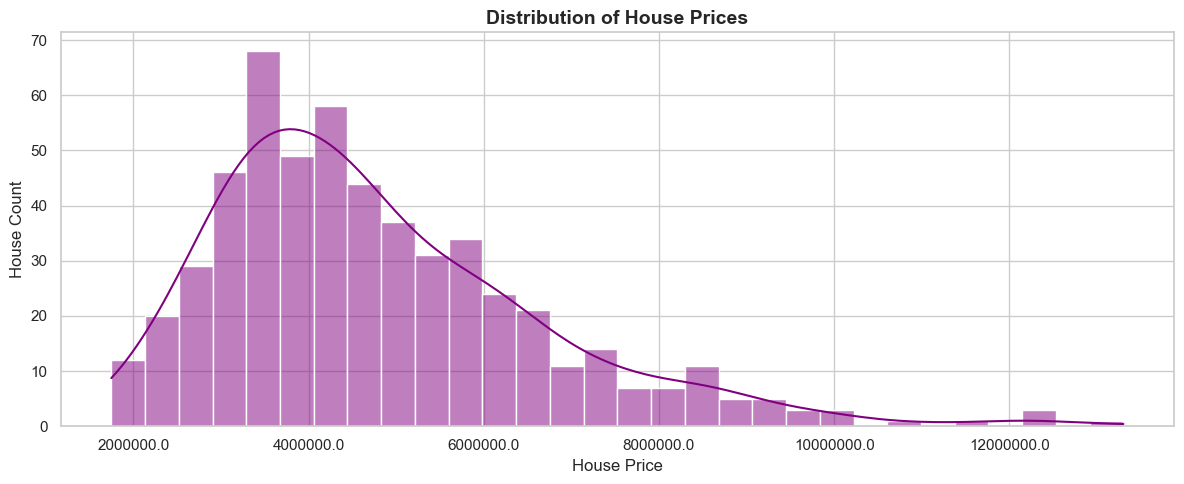

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,5))
sns.histplot(df['price'], kde = True, color = 'purple', bins = 30)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:}"))

plt.title("Distribution of House Prices", fontsize = 14, fontweight = 'bold')
plt.xlabel("House Price", fontsize = 12)
plt.ylabel("House Count", fontsize = 12)
plt.tight_layout()
plt.show()

Chart-2: Correlation Heatmap for feature Importance...

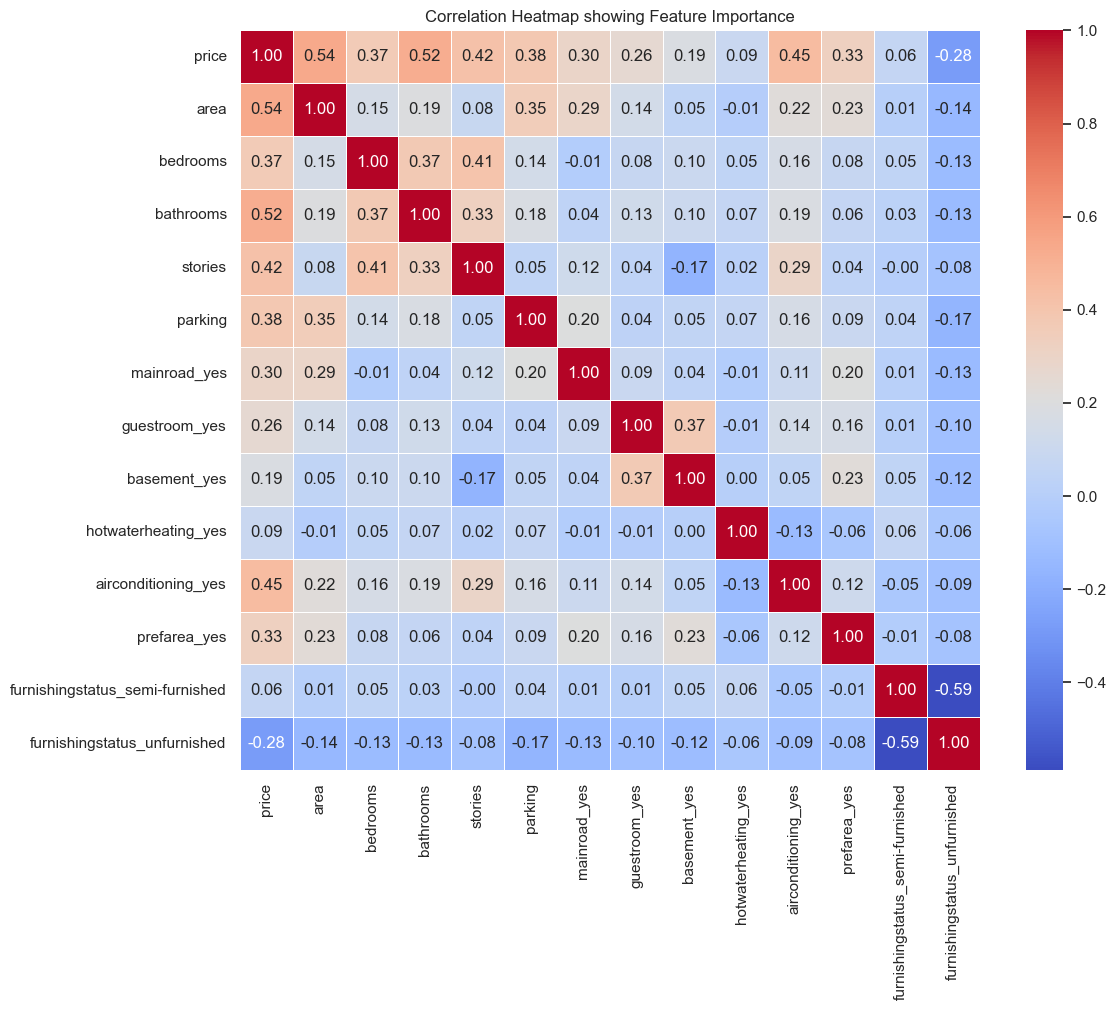

In [11]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    square=True
)

plt.title("Correlation Heatmap showing Feature Importance")
plt.tight_layout()
plt.show()

Chart-3: Comparing Models with Actual Price:

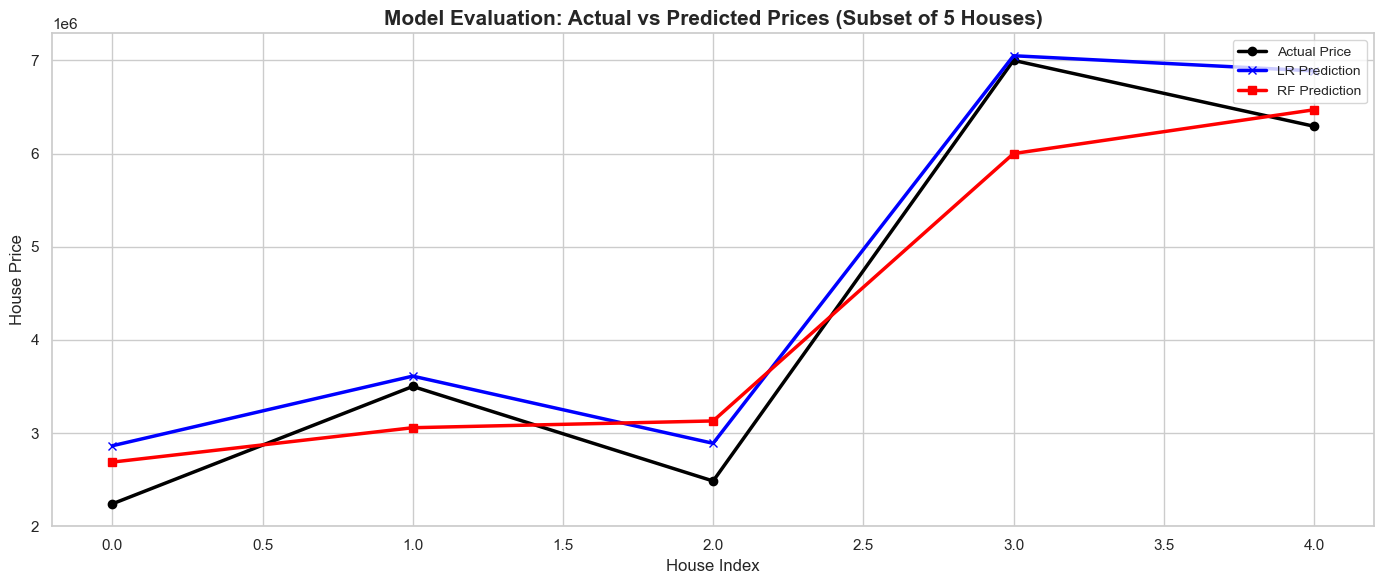

In [12]:
sns.set_theme(style = 'whitegrid')
num_samples = 5

plt.figure(figsize=(14,6))

plt.plot(range(num_samples), y_test.values[:num_samples],
        label = 'Actual Price', color = 'black', linewidth = 2.5, marker = 'o')
plt.plot(range(num_samples), lr_pred[:num_samples],
        label = 'LR Prediction', color = 'blue', linewidth = 2.5, marker = 'x')
plt.plot(range(num_samples), rf_pred[:num_samples],
        label = 'RF Prediction', color = 'red', linewidth = 2.5, marker = 's')

plt.title(f"Model Evaluation: Actual vs Predicted Prices (Subset of {num_samples} Houses)", fontsize = 15, fontweight = 'bold')
plt.xlabel("House Index", fontsize = 12)
plt.ylabel("House Price", fontsize = 12)
plt.legend(fontsize = 10, loc = 'upper right')
plt.tight_layout()
plt.show()